In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
#import tushare as ts
#from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torch.utils.data import TensorDataset
#from tqdm import tqdm
import torch.nn.functional as F
#import scipy.io as scio
import time 

In [2]:
import scipy
data = scipy.io.loadmat('real3d.mat')
Dn=data['DataNoisey']


In [3]:
def patch3d(A, l1=4, l2=4, l3=4, s1=2, s2=2, s3=2):
    """
    Optimized patch3d function using stride tricks to improve efficiency
    """
    # Pad the array if necessary to ensure dimensions are divisible by patch sizes
    pad1 = (l1 - A.shape[0] % s1) % s1
    pad2 = (l2 - A.shape[1] % s2) % s2
    pad3 = (l3 - A.shape[2] % s3) % s3
    A_padded = np.pad(A, ((0, pad1), (0, pad2), (0, pad3)), mode='constant')

    # Get new dimensions
    n1, n2, n3 = A_padded.shape
    n1_patches = (n1 - l1) // s1 + 1
    n2_patches = (n2 - l2) // s2 + 1
    n3_patches = (n3 - l3) // s3 + 1

    # Generate the sliding window view
    shape = (n1_patches, n2_patches, n3_patches, l1, l2, l3)
    strides = (s1 * A_padded.strides[0], s2 * A_padded.strides[1], s3 * A_padded.strides[2]) + A_padded.strides
    patches = np.lib.stride_tricks.as_strided(A_padded, shape=shape, strides=strides)

    # Reshape patches to (num_patches, patch_size) format
    patches = patches.reshape(-1, l1 * l2 * l3)
    return patches


def patch3d_inv(X, n1, n2, n3, l1=4, l2=4, l3=4, s1=2, s2=2, s3=2):
    """
    Reconstruct 3D data from 1D patches with optimized inverse patching.

    INPUT
    X: Patches in (num_patches, patch_size) format
    n1, n2, n3: Original 3D data dimensions
    l1, l2, l3: Patch sizes along each dimension
    s1, s2, s3: Shifts between patches along each dimension

    OUTPUT
    A: Reconstructed 3D data
    """

    # Initialize the padded 3D array and mask
    pad1 = (l1 - n1 % s1) % s1
    pad2 = (l2 - n2 % s2) % s2
    pad3 = (l3 - n3 % s3) % s3
    A = np.zeros((n1 + pad1, n2 + pad2, n3 + pad3))
    mask = np.zeros_like(A)

    # Reshape 1D patches to the 3D patch size for easier handling
    X = X.reshape(-1, l1, l2, l3)

    # Calculate the number of patches along each dimension
    n1_patches = (A.shape[0] - l1) // s1 + 1
    n2_patches = (A.shape[1] - l2) // s2 + 1
    n3_patches = (A.shape[2] - l3) // s3 + 1

    # Iterate over each patch and place it into the appropriate location
    idx = 0
    for i in range(n1_patches):
        for j in range(n2_patches):
            for k in range(n3_patches):
                # Place the current patch in the reconstruction array and update mask
                A[i * s1:i * s1 + l1, j * s2:j * s2 + l2, k * s3:k * s3 + l3] += X[idx]
                mask[i * s1:i * s1 + l1, j * s2:j * s2 + l2, k * s3:k * s3 + l3] += 1
                idx += 1

    # Avoid division by zero by replacing zeros with ones in the mask before division
    mask[mask == 0] = 1
    A /= mask

    # Trim padding to match the original dimensions
    return A[:n1, :n2, :n3]

In [4]:
w1 = 12
w2 = 12
w3 = 12
z1 = 4
z2 = 2
z3 = 2

dataInput = patch3d(Dn,w1,w2,w3,z1,z2,z3)
#dataInputP = np.transpose(dataInputP)
#dataPatches = np.reshape(dataInput,(dataInput.shape[0],w1*w2*w3))
dataInput = dataInput.astype(np.float32)
Pdata = torch.from_numpy(dataInput)
print(Pdata.dtype)
dataPatches = np.array(dataInput)
print(dataPatches.shape)

torch.float32
(31806, 1728)


In [5]:
# 数据分割：80% 训练数据，20% 验证数据
train_size = int(len(Pdata) * 0.8)
train = Pdata[:train_size]
valid = Pdata[train_size:]

# 打印训练集和验证集的形状
print(f"Train shape: {train.shape}")
print(f"Valid shape: {valid.shape}")
#创建 TensorDataset
train_data = TensorDataset(train)
valid_data = TensorDataset(valid)

# 设置 batch_size
batch_size1 = 64


# 创建 DataLoader
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size1, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_data, batch_size=batch_size1, shuffle=True)

Train shape: torch.Size([25444, 1728])
Valid shape: torch.Size([6362, 1728])


In [6]:
#定义Fully connected (FC) block
class FCB(nn.Module):
    def __init__(self, input_size, output_size, dropout=0.1):
        super().__init__()
        
        self.fc = nn.Linear(input_size, output_size)
        self.activation = nn.LeakyReLU()
        self.bn = nn.BatchNorm1d(output_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc(x)
        x = self.activation(x) 
        x = self.bn(x)
        x = self.dropout(x)
        
        return x

In [7]:
class SAB(nn.Module):  ## Self-Attention Block
    def __init__(self, input_size, output_size, dropout=0.1):
        super().__init__()
        self.fcb1 = FCB(input_size, output_size, dropout)  # Query
        self.fcb2 = FCB(input_size, output_size, dropout)  # Key
        self.fcb3 = FCB(input_size, output_size, dropout)  # Value
        self.fcb4 = FCB(input_size, output_size, dropout)  # Residual
        self.bn = nn.BatchNorm1d(output_size)
        self.softmax = nn.Softmax(dim=-1)
        self.adjust_dim = nn.Linear(input_size, output_size)  # 调整维度

    def forward(self, x):
        query = self.fcb1(x)
        key = self.fcb2(x)
        value = self.fcb3(x)
        residual = self.fcb4(x)

        # 自注意力机制
        attention_scores = torch.matmul(query, key.transpose(-1, -2))  # Q * K^T
        attention_scores = self.softmax(attention_scores)  # 对注意力分数应用 Softmax
        weighted_sum = torch.matmul(attention_scores, value)  # 加权求和
        weighted_sum = self.bn(weighted_sum)  # 对加权求和的结果应用批归一化

        # 残差连接
        if residual.size(1) != weighted_sum.size(1):
            residual = self.adjust_dim(residual)  # 调整维度
        output = weighted_sum + residual  # 残差连接

        return output

In [8]:
class MHB1(nn.Module):  ## Multi-Head Block
    def __init__(self, input_size, output_size, dropout=0.1, num_sabs=3, out_channels=1):
        super().__init__()
        self.num_sabs = num_sabs
        self.sabs = nn.ModuleList([SAB(input_size, output_size, dropout) for _ in range(num_sabs)])
        self.cov1d = nn.Conv1d(in_channels=num_sabs, out_channels=out_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        # 通过多个 SAB 提取特征
        sab_outputs = [sab(x) for sab in self.sabs]  # 每个 SAB 的输出形状: (batch_size, seq_len, feature_dim)
        
        # 将 SAB 的输出拼接在一起
        x = torch.stack(sab_outputs, dim=1)  # 形状: (batch_size, num_sabs, seq_len, feature_dim)
        
        # 调整形状以适应 Conv1d 的输入要求
        # 在这个地方写一个print（x.shape）,看看形状和预期的是不是一样的，然后再运行下
      #  print(f"MHB A :{x.shape}")
        x = x.permute(0, 1, 2)  # 形状: (batch_size, num_sabs, feature_dim, seq_len)
        x = self.cov1d(x)  # 形状: (batch_size, out_channels, seq_len)
      #  print(f"MHB 1 :{x.shape}")
        
        x = x.reshape(x.size(0), x.size(1) * x.size(2)* x.size(3))  # 合并通道维度: (batch_size, num_sabs * feature_dim, seq_len)
      #  print(f"MHB 2 :{x.shape}")
        
        # 应用 Conv1d
      
       # print(f"MHB end :{x.shape}")

        return x

In [9]:
class MHB0(nn.Module):  ##multi head block
    def __init__(self, input_size, output_size, dropout=0.1):
        super().__init__()
        self.sab1 = SAB(input_size, output_size, dropout)
        self.sab2 = SAB(input_size, output_size, dropout)
        self.cov1d = nn.Conv1d(in_channels=2, out_channels= 1, kernel_size = 3, stride=1, padding=1)


    def forward(self, x):
        #print(f"MHB00: {x.shape}")   
        x1 = self.sab1(x)
        x2 = self.sab2(x)
    
        x1 = x1.unsqueeze(1) 
        x2 = x2.unsqueeze(1) 

        # 添加一个维度
        #print(f"MHB01: {x1.shape}")
        x = torch.cat([x1, x2], dim=1)  # (B, L, 4*D)
        #print(f"MHB0: {x.shape}")
        x = self.cov1d(x)
        #print(f"MHB2: {x.shape}")

        x = x.squeeze() 
        #print(f"MHB4: {x.shape}")
    
        return x  

In [10]:
class MHB(nn.Module):  ##multi head block
    def __init__(self, input_size, output_size, dropout=0.1):
        super().__init__()
        self.sab1 = SAB(input_size, output_size, dropout)
        self.sab2 = SAB(input_size, output_size, dropout)
        self.sab3 = SAB(input_size, output_size, dropout)
        self.sab4 = SAB(input_size, output_size, dropout)
        self.cov1d = nn.Conv1d(in_channels=4, out_channels= 1, kernel_size = 3, stride=1, padding=1)


    def forward(self, x):
        #print(f"MHB00: {x.shape}")   
        x1 = self.sab1(x)
        x2 = self.sab2(x)
        x3 = self.sab3(x)
        x4 = self.sab4(x)
        x1 = x1.unsqueeze(1) 
        x2 = x2.unsqueeze(1) 
        x3 = x3.unsqueeze(1) 
        x4 = x4.unsqueeze(1) 
        # 添加一个维度
        #print(f"MHB01: {x1.shape}")
        x = torch.cat([x1, x2, x3, x4], dim=1)  # (B, L, 4*D)
        #print(f"MHB0: {x.shape}")
        x = self.cov1d(x)
        #print(f"MHB2: {x.shape}")

        x = x.squeeze() 
        #print(f"MHB4: {x.shape}")
    
        return x  

In [11]:
class TSB(nn.Module):  ##self attention block
    def __init__(self, input_size, output_size, dropout1=0.1, dropout2=0.18, dropout3=0.2):
        super().__init__()   
        self.mhb1 = MHB(input_size, output_size, dropout1)
        self.mhb2 = MHB(output_size, output_size, dropout2)
        self.mhb3 = MHB(output_size, output_size, dropout3)
        self.fc1 = nn.Linear(output_size, output_size)
        self.fc2 = nn.Linear(output_size, output_size)
        self.fc3 = nn.Linear(output_size, output_size)
    def forward(self, x):
        #print(f"TSBx: {x.shape}")

        x1 = self.mhb1(x)
        x2 = self.fc1(x1)
        x3 = x2+x1
        x4 = self.mhb2(x3)
        x5 = self.fc2(x4)
        x6 = x5+x4
       
        #print(f"TSB: {x9.shape}")

        return x6   

In [12]:
class EnCoder(nn.Module):
    def __init__(self, input_size, dropout1=0.2,dropout2=0.15, dropout3=0.1):
        super().__init__()
        self.adjust_dim = nn.Linear(input_size, 1024)  # 调整维度

        self.tsb = TSB(1024, 512, dropout1 =dropout1, dropout2=dropout2, dropout3=dropout3)
        self.mhb = MHB(512, 128, dropout  =dropout1)
        self.sab = SAB(128, 64, dropout =dropout1)
        self.fcb1 = FCB(64, 16, dropout =dropout1)
        self.fcb2 = FCB(16, 4, dropout =dropout1)

    def forward(self, x):
       # print(f"Encoder begin :{x.shape}")
        x = self.adjust_dim(x)  # 调整维度
      #  print(f"Encoder 1 :{x.shape}")
    #    print(f"Coder begin :{x.shape}")
        x1 = self.tsb(x)
        x2 = self.mhb(x1)
        x3 = self.sab(x2)
        x4 = self.fcb1(x3)
        x5 = self.fcb2(x4)

     #   print(f"Encoder 2 :{x8.shape}")

        return x1, x2, x3, x4, x5

In [13]:
class DeCoder(nn.Module):
    def __init__(self, output_size, dropout1=0.2, dropout2=0.15, dropout3=0.1):
        super().__init__()
        # 调整FCB维度，确保矩阵相加时维度匹配
        self.fcb1 = FCB(4, 16, dropout=dropout1)  # x5（4维）→16维（与x4维度匹配）
        self.fcb2 = FCB(16, 64, dropout=dropout1)  # 16维→64维（与x3维度匹配）
        
        # 添加维度调整层，确保矩阵相加时维度匹配
        self.adjust1 = nn.Linear(128, 128)  # 调整x2维度
        self.adjust2 = nn.Linear(512, 512)  # 调整x1维度
        
        self.sab = SAB(64, 128, dropout=dropout1)  # 64维→128维（与x2维度匹配）
        self.mhb = MHB(128, 512, dropout=dropout1)  # 128维→512维（与x1维度匹配）
        self.tsb = TSB(512, 1024, dropout1=dropout1, dropout2=dropout2, dropout3=dropout3)
        self.adjust_dim = nn.Linear(1024, output_size)  # 最终调整到输出维度

    def forward(self, x1, x2, x3, x4, x5):
        # 1. 低维特征升维 + 与编码器中间特征x4做矩阵相加（残差连接）
        x51 = self.fcb1(x5)  # x5（4维）→16维（与x4同维度）
        x4_add = x51 + x4  # 矩阵相加融合（16维+16维→16维）
        
        # 2. 升维 + 与编码器中间特征x3做矩阵相加（残差连接）
        x41 = self.fcb2(x4_add)  # 16维→64维（与x3同维度）
        x3_add = x41 + x3  # 矩阵相加融合（64维+64维→64维）
        
        # 3. 升维 + 与编码器中间特征x2做矩阵相加（残差连接）
        x31 = self.sab(x3_add)  # 64维→128维（与x2同维度）
        x2_adj = self.adjust1(x2)  # 调整x2维度以确保匹配
        x2_add = x31 + x2_adj  # 矩阵相加融合（128维+128维→128维）
        
        # 4. 升维 + 与编码器中间特征x1做矩阵相加（残差连接）
        x21 = self.mhb(x2_add)  # 128维→512维（与x1同维度）
        x1_adj = self.adjust2(x1)  # 调整x1维度以确保匹配
        x1_add = x21 + x1_adj  # 矩阵相加融合（512维+512维→512维）
        
        # 5. 最终升维与输出调整
        x = self.tsb(x1_add)  # 512维→1024维
        x = self.adjust_dim(x)  # 1024维→目标输出维度
        
        return x

In [14]:
class AutoCoder(nn.Module):
    def __init__(self, input_size,output_size):
        super().__init__()

        self.encoder = EnCoder(input_size)
        self.decoder = DeCoder(output_size)

    def forward(self, x):
    #    print(f"Coder begin :{x.shape}")
        x1,x2,x3,x4,x5 = self.encoder(x)
        x = self.decoder(x1,x2,x3,x4,x5)
        return x

In [15]:
input_dim=w1*w2
model = AutoCoder(input_size=input_dim, output_size=input_dim)
total_params = sum(p.numel() for p in model.parameters())
print(f"总参数量: {total_params:,}")

总参数量: 80,936,036


In [16]:
class L2TVLoss(nn.Module):
    def __init__(self, l2_weight=1.0, tv_weight=0.1):
        super(L2TVLoss, self).__init__()
        self.l2_weight = l2_weight  # L2 (MSE) 损失权重
        self.tv_weight = tv_weight  # TV 损失权重

    def forward(self, input, target):
        # L2 (MSE) 损失
        l2_loss = F.mse_loss(input, target, reduction='mean')

        # TV 损失（Total Variation Regularization）
        h_tv = torch.abs(input[:, 1:] - input[:, :-1]).sum()
        tv_loss = torch.mean(h_tv)

        # 组合损失
        total_loss = self.l2_weight * l2_loss + self.tv_weight * tv_loss
        return total_loss

In [17]:
class TukeysBiweightLoss(nn.Module):
    def __init__(self, c=4.685):
        super(TukeysBiweightLoss, self).__init__()
        self.c = c  # 阈值参数，默认4.685

    def forward(self, y_pred, y_true):
        """
        Args:
            y_pred: 模型预测值 (Tensor)
            y_true: 真实标签 (Tensor)
        Returns:
            loss: 计算后的Tukey's Biweight Loss (Tensor)
        """
        residual = y_true - y_pred
        abs_residual = torch.abs(residual)
        mask = (abs_residual <= self.c).float()  # 离群点掩码（|r| <= c时为1，否则为0）

        # 核心计算
        scaled_residual = residual / self.c
        term = 1 - scaled_residual ** 2
        loss = (self.c ** 2 / 6) * (1 - term ** 3) * mask  # 对离群点损失置0

        return loss.mean()  # 返回均值损失

In [18]:
class HuberTVLoss(nn.Module):
    def __init__(self, huber_delta=1.0, tv_weight=1e-3, huber_weight=1.0):
        super(HuberTVLoss, self).__init__()
        self.huber_delta = huber_delta      # Huber Loss的阈值δ
        self.tv_weight = tv_weight          # TV Loss的权重β
        self.huber_weight = huber_weight    # Huber Loss的权重α

    def huber_loss(self, y_pred, y_true):
        """Huber Loss实现"""
        residual = y_true - y_pred
        abs_residual = torch.abs(residual)
        quadratic = torch.clamp(abs_residual, max=self.huber_delta)
        linear = abs_residual - quadratic
        return 0.5 * quadratic.pow(2) + self.huber_delta * linear

    def tv_loss(self, x):
        """Total Variation Loss实现（图像平滑正则化）"""
        # 计算水平和垂直方向的梯度
        batch_size = x.size(0)
        h_grad = torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :])  # 高度方向差分
        w_grad = torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1])  # 宽度方向差分
        return (h_grad.sum() + w_grad.sum()) / batch_size      # 归一化到batch维度

    def forward(self, y_pred, y_true):
        """
        Args:
            y_pred: 模型输出 (Tensor, 形状为[B, C, H, W]的图像或[B, N]的向量)
            y_true: 真实标签 (Tensor, 形状与y_pred相同)
        Returns:
            total_loss: 联合损失值
        """
        # 计算Huber Loss
        huber = self.huber_loss(y_pred, y_true).mean()  # 均值处理

        # 计算TV Loss（若输入是图像）
        if y_pred.dim() == 4:  # 图像数据 [B, C, H, W]
            tv = self.tv_loss(y_pred)
        else:  # 非图像数据（如向量），TV Loss设为0
            tv = torch.tensor(0.0, device=y_pred.device)

        # 联合损失
        total_loss = self.huber_weight * huber + self.tv_weight * tv
        
        return total_loss

In [19]:
class TanhLoss(nn.Module):
    def __init__(self):
        super(TanhLoss, self).__init__()


    def tan_loss(self, y_pred, y_true):
        """Huber Loss实现"""
        residual =torch.tanh(y_true)-torch.tanh(y_pred)
        abs_residual = torch.abs(residual)
        loss = abs_residual.sum()/(2*y_pred.numel())
        return loss


    def forward(self, y_pred, y_true):
        """
        Args:
            y_pred: 模型输出 (Tensor, 形状为[B, C, H, W]的图像或[B, N]的向量)
            y_true: 真实标签 (Tensor, 形状与y_pred相同)
        Returns:
            total_loss: 联合损失值
        """
        # 计算Huber Loss
        loss1 = self.tan_loss(y_pred, y_true)  # 均值处理

 
        
        return loss1

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 初始化模型并移动到设备
#model = Coder(w1 * w2, w1 * w2).to(device)
model = AutoCoder(input_size=w1*w2*w3,output_size=w1*w2*w3).to(device)
# 初始化损失函数
#criterion = Loss0(delta=0.36,r=0.5)
#criterion = L2TVLoss(l2_weight=0.3, tv_weight=0.7)
#criterion =TukeysBiweightLoss(c=9)
#criterion =TanhLoss()

criterion = HuberTVLoss(huber_delta=0.54, tv_weight=0.01, huber_weight=5.33)

# 初始化优化器
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

Using device: cuda


In [21]:
start_time = time.time()
es_cnt = 0
es_thres = 5
prev_valid_loss = float('inf')
loss_train = []
loss_valid = []
num_epochs = 200 # 总训练轮数

for epoch in range(num_epochs):
    # 训练
    model.train()
    train_loss = 0.0
    for i, (batch) in enumerate(train_loader):
        # 数据转到 device
        train_batch = batch[0].to(device)
        if epoch == 0 and i == 0:
            print("\n========== 数据维度 & 数值范围 摸底 ==========")
            # 1. 打印原始输入批次的维度
            print(f"【输入数据维度】train_batch.shape: {train_batch.shape}")
            print(f"  - 批次大小（第0维）: {train_batch.shape[0]}")
            print(f"  - 通道数（第1维）: {train_batch.shape[1] if len(train_batch.shape)>=2 else '无'}")
            print(f"  - 高度（第2维）: {train_batch.shape[2] if len(train_batch.shape)>=3 else '无'}")
            print(f"  - 宽度（第3维）: {train_batch.shape[3] if len(train_batch.shape)>=4 else '无'}")
            
            # 2. 打印数值范围（保留你原来的max/min）
            print(f"\n【输入数据数值范围】")
            print(f"  - 最大值: {train_batch.max().item():.6f}")
            print(f"  - 最小值: {train_batch.min().item():.6f}")
            print(f"  - 平均值: {train_batch.mean().item():.6f}")
            print("==============================================\n")

        if epoch == 0 and i == 0:
            print("\n========== 真正的数据分布揭秘 ==========")
        # 抛弃极端的 1% 噪声，看剩下 99% 数据（通常是真实信号）的绝对振幅有多大
            q99 = torch.quantile(train_batch.abs(), 0.99).item()
            print("99% 的数据绝对值都在这个数值以下:", q99)
            print("数据的标准差 (均值附近的波动范围):", train_batch.std().item())
            print("======================================\n")
        
        # 训练步骤
        optimizer.zero_grad()
        outputs = model(train_batch)
        loss = criterion(outputs, train_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    # 计算平均训练损失
    train_loss = train_loss / (np.ceil(train.size(0) / batch_size1))
    loss_train.append(train_loss)
    
    # 验证
    model.eval()
    valid_loss = 0.0
    with torch.no_grad():
        for i, (batch) in enumerate(valid_loader):
            val_batch = batch[0].to(device)
            outputs = model(val_batch)
            loss = criterion(outputs, val_batch)
            valid_loss += loss.item()
    
    # 计算平均验证损失
    valid_loss = valid_loss / (np.ceil(valid.size(0) / batch_size1))
    loss_valid.append(valid_loss)
   
    # 打印当前 epoch 的损失
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}")
    
    # Early stopping
    if valid_loss >= prev_valid_loss:
        es_cnt += 1
    else:
        es_cnt = 0

    if es_cnt >= es_thres:
        print(f"Early stopped at epoch {epoch}, validation loss stop improving")
        break

    prev_valid_loss = valid_loss

# 打印最终损失记录
print('Final Train Loss: ', loss_train)
print('Final Valid Loss: ', loss_valid)

# 打印总训练时间
current_time = time.time()
time_sum = current_time - start_time
time_sum_minutes = time_sum / 60
print(f"Total training time: {time_sum_minutes:.2f} minutes")


========== 数据维度 & 数值范围 摸底 ==========
【输入数据维度】train_batch.shape: torch.Size([64, 1728])
  - 批次大小（第0维）: 64
  - 通道数（第1维）: 1728
  - 高度（第2维）: 无
  - 宽度（第3维）: 无

【输入数据数值范围】
  - 最大值: 4.709731
  - 最小值: -5.186745
  - 平均值: 0.025338


========== 真正的数据分布揭秘 ==========
99% 的数据绝对值都在这个数值以下: 1.7350107431411743
数据的标准差 (均值附近的波动范围): 0.6492091417312622

Epoch [1/200], Train Loss: 1.1237, Valid Loss: 0.8888
Epoch [2/200], Train Loss: 0.8423, Valid Loss: 0.8438
Epoch [3/200], Train Loss: 0.7567, Valid Loss: 0.8179
Epoch [4/200], Train Loss: 0.7149, Valid Loss: 0.7951
Epoch [5/200], Train Loss: 0.6943, Valid Loss: 0.7776
Epoch [6/200], Train Loss: 0.6800, Valid Loss: 0.7615
Epoch [7/200], Train Loss: 0.6679, Valid Loss: 0.7522
Epoch [8/200], Train Loss: 0.6569, Valid Loss: 0.7419
Epoch [9/200], Train Loss: 0.6466, Valid Loss: 0.7322
Epoch [10/200], Train Loss: 0.6384, Valid Loss: 0.7273
Epoch [11/200], Train Loss: 0.6310, Valid Loss: 0.7199
Epoch [12/200], Train Loss: 0.6232, Valid Loss: 0.7109
Epoch [13/200]

KeyboardInterrupt: 

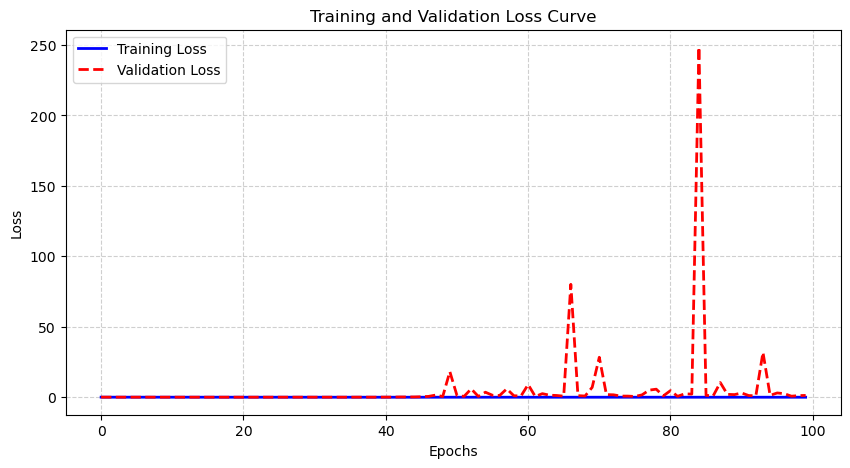

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(loss_train, label='Training Loss', color='blue', linewidth=2)
plt.plot(loss_valid, label='Validation Loss', color='red', linestyle='--', linewidth=2)
plt.title('Training and Validation Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
# 如果你想保存图片，可以取消下面这行的注释
# plt.savefig('loss_curve.png', dpi=300)
plt.show()

In [24]:
loss_train = pd.DataFrame(loss_train)
loss_valid = pd.DataFrame(loss_valid)

loss = pd.concat([loss_train,loss_valid],axis=1)

In [25]:
loss.columns = ['train_loss','valid_loss']

In [26]:
torch.save(model.state_dict(), r'.\model_trans_real3d2.pth')

In [31]:
model = AutoCoder(w1*w2*w3,w1*w2*w3).to(device)
Pdata = Pdata.to(device)
model.load_state_dict(torch.load(r'.\model_trans_real3d2.pth'))
model.eval()
with torch.no_grad():
    output = model(Pdata)
    loss = criterion(output, Pdata)
output = output.cpu()
output = output.numpy()
# ========== 新增：重构去噪后的数据并计算信噪比 ==========
# 重构去噪后的数据
n1 = Dn.shape[0]  # 对应MATLAB：n1 = size(Dn, 1)
n2 = Dn.shape[1]  # 对应MATLAB：n2 = size(Dn, 2)
n3 = Dn.shape[2]  # 对应MATLAB：n3 = size(Dn, 3)
D_denoised = patch3d_inv(output,n1,n2,n3,w1,w2,w3,z1,z2,z3)
scipy.io.savemat(r"output_trans_real3d2.mat", 
        {'D_denoised': D_denoised})  # 'D_denoised'是MAT文件里的变量名
print("推理完成")

In [30]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()